# Homework 4B: Deep Object Recognition

<small>v1.0</small>

**DUE DATE**: March 12, 11:59pm Pacific via Canvas

* **Tip:** Start with HW4A, as this assignment requires L15 and Keras will be introduced on Friday
* You can save a copy of this document in your own Drive and work on it in your own Colab
* You can add comments, multiple cells, etc. Just make sure to explain what you did so that we can give you partial credit if necessary
* Make sure to rely only on allowed Python libraries. Each problem will state what's allowed
* When you're done, go to "Runtime > Restart session and run all" to make sure your notebook runs correctly from top to bottom
* **You need to submit two things: an .ipynb and .pdf file.** Go to "File > Download > Download .ipynb" to download the raw Jupyter Notebook file. Then go to "File > Print" and choose "Save as PDF" (or similar). **Make sure the files were produced correctly (sometimes long files get truncated).** We can only grade what you submit. Then upload both files (and the files from HW2A) to the Canvas assignment folder.
* Remember, you are expected to work alone. You can ask questions on Piazza or discuss a solution approach with your peers, but you must not copy their code.
The implementation must be yours. **AI may only be used as outlined in the course's AI-use policy - all AI use must be disclosed below.**

Changelog:
- v1.0: Initial version

--

AI DISCLOSURE:

Used AI to clarify some concepts, help debug code, and explain certain functions/libraries used.

--

# 1. Getting Started with Keras (2 pts)

## 1.1 Intro to Keras

Keras is a deep learning API written in Python, running on top of the machine learning platform [TensorFlow](https://www.tensorflow.org/). It was developed with a focus on enabling fast experimentation.

If you're unfamiliar with TensorFlow, we have already seen a little bit of it in action when we messed around with the [TensorFlow Playgroun](https://playground.tensorflow.org).
TensorFlow is an end-to-end, open-source machine learning platform. You can think of it as an infrastructure layer for differentiable programming. It combines four key abilities:
- Efficiently executing low-level tensor operations on CPU, GPU, or TPU.
- Computing the gradient of arbitrary differentiable expressions.
- Scaling computation to many devices (e.g. the Summit supercomputer at Oak Ridge National Lab, which spans 27,000 GPUs).
- Exporting programs ("graphs") to external runtimes such as servers, browsers, mobile and embedded devices.

Like many other useful tools, Keras comes pre-installed with Google Colab:

In [3]:
from tensorflow import keras

The core data structures of Keras are `layers` and `models`. The simplest type of model is the `Sequential` model, a linear stack of layers.



In [4]:
from tensorflow.keras.models import Sequential

## 1.2 Generating a toy dataset

Before we can build a useful model, we need some data.

We'll be using [scikit-learn](https://scikit-learn.org) for this - because it provides an easy way to generate some sample data.

Let's generate 500 data points lying on one of two concentric circles. The data points on the inner circle will be of class 0 and data points on the outer circle will be of class 1. We'll also add a little bit of noise:



In [5]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
print(X.shape)
print(y.shape)

It is custom to call the feature matrix `X` (or `X_train`, `X_test`) and the vector of target labels (classes) `y` (or `y_train`, `y_test`).
You can see from the above output that our feature matrix `X` has shape 500x2, meaning it has 500 data points with two features each.
The `y` vector simply stores the target label for each data point, so it should have shape 500x1.

We can visualize the data as follows:

In [6]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y)

Now we're ready to build our first neural network.

We'll start with an empty `Sequential` model and then add two layers:
- The first layer has 4 neurons in it: both input features are connected to all neurons in the layer. This is known as an "all-to-all" or "dense" connection. Hence we use the `Dense` layer. We'll add a ReLU as activation function.
- The second layer has 2 neurons in it: all 4 neurons of the previous layer are connected to both neurons in this layer. This is again a `Dense` layer with a ReLU activation function:
- The output layer has a single neuron in it: its activation will determine the class we're predicting (activation < 0.5: class 0, activation >= 0.5, class 1)

In [7]:
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(4, activation='relu'))  # model.add(Dense(4, activation='relu', input_shape=(2,0)))
model.add(Dense(2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

In [8]:
keras.utils.plot_model(model, show_shapes=True)

To allocate the weights, each layer needs to know the number of its inputs. In a hidden layer, this is inferred automatically. However, the first layer can't automatically guess what input data you're going to present, so you need to tell it the right `input_shape` or define an `Input layer` as we have done before your first hidden layer.

By default, each layer uses a bias vector (`use_bias=True`), whose values do not depend on the input features. This allows the layer to do calculate `y_hat=ReLU(ax+b)` instead of just `y_hat=ReLU(ax)`.



## 1.3 **TODO:** Differences to TensorFlow Playground (1 pt)

Guess what! This is (almost) the same as the default network you see when you first open [TensorFlow Playground](https://playground.tensorflow.org).
We're not sure what loss function they used, or whether they included a bias vector. But what are some other differences between ours and Playground?

Name at least two:

---

One difference between ours and the tensorflow playground is that our our playground uses a ReLu as the activation function while the tensorflow playgroud uses a Tanh activation function. Additionally, another difference is the tensorflow playground has two output neurons while our playground only has one output neruon.

---

## 1.4 **TODO:** Training the model (1 pt)

Now we are ready to train the model.

First we need to build it by translating the network specifications above into an executable network. This is done with `compile`. Here we have the option to specify which [loss function](https://keras.io/api/losses/) to use (e.g., mean squared error), which [solver](https://keras.io/api/optimizers/) to use (e.g., stochastic gradient descent, adam), which metrics to output (e.g., accuracy), etc.

Since this is a classification task, we want to use the cross-entropy loss.

We'll also use stochastic gradient descent (SGD) with a 0.03 learning rate (just like Playground):


In [9]:
model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.SGD(learning_rate=0.03),
              metrics=['accuracy'])

Then we're ready to train the model using the same batch size as Playground.

But what does batch size 10 mean?

---

A batch size of 10 means that after every 10 samples, the gradient is caluclated and the model's weights are updated.

---

We will also hold out 20% of the training data as a "validation set". This validation set serves a similar purpose as the test set - to monitor the model's generalization error as training progress. Often training is stopped as soon as the validation error does not decrease after a few iteration (aka "early stopping"). This allows you to specify a "large enough" number for the number of iterations, and early stopping will make sure to quit the training process as soon as the validation error does not get better.

In [10]:
from tensorflow.keras.callbacks import EarlyStopping
history = model.fit(X, y, batch_size=10, epochs=300, validation_split=0.2)
                    # callbacks=[EarlyStopping(monitor='val_loss', patience=5)]) can also add Tensorboard here which is Tf's visualization toolkit

We can now use the `history` variable to visualize the progression of the loss (and the validation loss) over time:


In [11]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

## 1.5 Plotting the decision boundaries

Your network should achieve 100% accuracy after 200 epochs. We could look at some other metrics to convince ourselves that the network did a good job. Or we could visualize the decision boundaries, like TensorFlow Playground does.

There are probably some useful third-party libraries for this, but in principle, the idea is to feed all possible combinations of input features to the model and look at the predictions:

In [12]:
# Create a mesh grid of (x1,x2) feature values:
import numpy as np
x1, x2 = np.meshgrid(np.arange(-1.5, 1.5, 0.1),
                     np.arange(-1.5, 1.5, 0.1))

# Have the model predict the labels:
zz = model.predict(np.vstack((x1.ravel(), x2.ravel())).T)

# Convert from one-hot encoding back to [0, 1] labels (explained in 2.1):
zz = np.int32(zz[:, 0] >= 0.5).reshape(x1.shape)

# Plot it:
plt.contourf(x1, x2, zz)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')

You should see that all yellow data points lie in the yellow region, and all blue data points lie in the blue region. This confirms that the network correctly classified all data points!

Now let's look at a more complicated example.

In [13]:
model_example = keras.Sequential([
    keras.Input(shape=(50,50,0)),

    keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [14]:
keras.utils.plot_model(model_example, show_shapes=True)

<hr>

# 2. Getting Started with CNNs (8 pts)

In this section we want to build a CNN for handwritten digit classification using the MNIST dataset.

## 2.1 Loading the MNIST dataset

The first step is to load the dataset. Fortunately, it comes bundled with Keras:

In [15]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

The dataset has already been split into training and test data. Printing the shape of these variables reveals the size of the dataset:

In [16]:
print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

From this we can see that MNIST contains 60,000 training samples and 10,000 test samples. Each image is 28x28 pixels.

For each of these training samples, we also have a class label indicating which digit this image is shown (0-9).

To make this dataset work with Keras, we need to make sure input image size is 28x28x1, not 28x28. We'll also scale the images to the [0,1] range:

In [17]:
# Scale to [0,1]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Make sure images have shape (28, 28, 1):
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

Finally, we need to transform the labels from an integer (0–9) into a vector representation using **one-hot encoding**.

This step was not covered in lecture, but it is a common preprocessing step when training classification networks. Sections and homework sometimes introduce practical tools like this that complement the concepts discussed in lecture.

Our network will have 10 output neurons, one for each digit class (0-9). The output layer will use softmax, which produces a probability distribution over these classes. During training, the network compares this predicted distribution to the target distribution representing the correct label.

Instead of representing the label as a single integer (e.g., 3), we represent it as a vector where all entries are zero except for the correct class.

For example, digit 0 is encoded as:

    [1 0 0 0 0 0 0 0 0]

Digit 1 is encoded as:

    [0 1 0 0 0 0 0 0 0]

Digit 3 is encoded as:

    [0 0 0 1 0 0 0 0 0]

This representation allows the network to learn which output neuron should assign the highest probability for each input image.

Fortunately, we do not need to implement this ourselves. Keras provides a utility function that converts integer labels to one-hot vectors:

In [18]:
# For future reference:
num_classes = len(np.unique(y_train))
img_shape = X_train.shape[1:]

from keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

## 2.2 **TODO:** Building our first model (5 pts)

Now on to the network architecture. We will start simple:

- Add a single convolutional layer with 4 3x3 kernels and ReLU activation.
- Add a max pooling layer with 2x2 pool size and stride 2
- Add a dense layer with softmax activation.

In [19]:
from keras import layers
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(4, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

In [20]:
model.summary()

**TODO:** How many trainable parameters does the movel have?

> Hint: Have a look at `model.summary`

---

There are 6,810 trainable parameters

---

## 2.3 Training the model (2 pts)

OK let's train the model and see how good it is.

We'll use stochastic gradient descent with batch size 128. We'll train for at least 50 epochs (but use early stopping; and you're welcome to run longer) and calculate accuracy. Each epoch should only take 15 seconds, so this might take 12-15 minutes to run.

> *Hint*: Alternatively, you can go to Runtime > Change runtime type and select either GPU or TPU to speed up the learning process.

In [21]:
from tensorflow.keras.callbacks import EarlyStopping
from keras.optimizers import SGD

model.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.01),metrics=['accuracy'])
history = model.fit(X_train, y_train, batch_size=128, epochs=50, validation_split=0.2,
                    callbacks=[EarlyStopping(monitor='val_loss', patience=5)])

Plot the training and validation error in each epoch of the training process:

In [22]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

## 2.4 **TODO**: Evaluating the model (1 pt)

In the cell below, print the loss and accuracy on train and tests:

> Hint: Have a look at `model.evaluate`

In [23]:
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f}", f"Train Loss: {train_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}", f"Test Loss: {test_loss:.4f}")

Is the model overfitting, underfitting, or just right? Do the training/test accuracy agree with what you expected?

---

The model fits just right. Looking at the accuracy of our test and training dataset, they are both above 90% and are very close to each other. The training accuracy is 95.49% while the testing accuracy is 95.28%, demonstrating a just rit model fitting.

---

# 3. Building LeNet-5 (10 pts)

A network with one convolutional layer is not exactly deep, so let's add some layers.

## 3.1 **TODO:** Building the network (4 pts)

In the cell(s) below, implement LeNet-5 as discussed in class.

To be clear, your network should look like this:



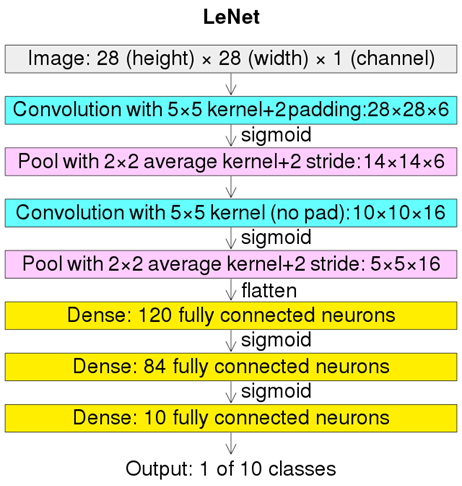

> Hints:
> - You'll have to specify the input shape for the first layer.
> - You can either specify the activation function as part of the convolutional/dense layer call, or add a stand-alone activation layer after it.
> - Instead of specifying number of pixels for `padding`, read the docs to figure out which string gives you the expected output.
> - Finally, don't forget to add a softmax activation after the last Dense layer.

In [50]:
from tensorflow.keras import layers, models

model = models.Sequential([layers.Input(shape=(28, 28, 1)),
                           layers.Conv2D(6, kernel_size=(5, 5), padding='same', activation='sigmoid'),
                           layers.AveragePooling2D(pool_size=(2, 2), strides=2),
                           layers.Conv2D(16, kernel_size=(5, 5), padding='valid', activation='sigmoid'),
                           layers.AveragePooling2D(pool_size=(2, 2), strides=2),
                           layers.Flatten(),
                           layers.Dense(120, activation='sigmoid'),
                           layers.Dense(84, activation='sigmoid'),
                           layers.Dense(10, activation='softmax')])

Print a model summary to make sure you got all the layers/dimensions right:

In [25]:
model.summary()

How many trainable parameters does the model have? Which layer type is responsible for the majority of these parameters?

---

The model has 61,706 trainable parameters. The dense layers are responsible for majority of these parameters with dense_7 having 48,120 trainable parameters and dense_9 having 10,164 trainable parameters.

---

## 3.2 **TODO:** Training the model (1 pt)

To train the model, use the categorical cross-entropy loss and the adam optimizer with a batch size of 128 or 256.
Train for at least 10 epochs (should take roughly 5 minutes).
Add accuracy as a metric.
Set aside 20% of your training data for validation.


Make sure to store the output of `model.fit` in a variable, so that you can plot the training and validation error as training progress (like we did in Section 1 above).

In [26]:
model.compile(optimizer=optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history =  model.fit(X_train, y_train, batch_size=128, epochs=10, validation_split=0.2)

## 3.3 Visualizing training progression

If you followed the hint above, you should have stored the output of `model.fit` in a variable. Now we can use this variable to visualize the progression of the loss (and the validation loss) over time:

In [27]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

## 3.4 **TODO**: Evaluating model performance (1 pt)

Now use your trained model to calculate the accuracy on the train and test set:

In [28]:
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f}", f"Train Loss: {train_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}", f"Test Loss: {test_loss:.4f}")

Is the model overfitting, underfitting, or just right?

---

The model is fitting just right. Both the training and testing accuracy are very close to each other and are well above 90%. The training accuracy was 97.60% and the testing accuracy was 97.46%, demonstrating a just right fitting.

---


## 3.5 **TODO:** Visualizing what the network learns (4 pts)

In the cell(s) below, visualize the weigths that each neuron in the *first convolutional layer* learned. Ideally you would write a function that takes in the weights of a layer and then plots the learned weights for each neuron in the layer in a Matplotlib subplot.

> Hints:
> - You can access the weights of a layer with `model.layers[n].get_weights()[0]`, where `n` specifies the `n`-th layer in the network. Call `shape` on it to see its dimensions
> - Here's a recipe to make a 3x5 subplots grid using Matplotlib:
>       import matplotlib.pyplot as plt
>       nrows, ncols = 3, 5
>       fig, axes = plt.subplots(nrows, ncols)
>       axes[0, 1].imshow(my_img) # display an image in the first row, second column

In [48]:
# 2 pts
import matplotlib.pyplot as plt

def visualize_filters(weights):
  nrows, ncols = 3, 5
  fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6))

  num_filters = weights.shape[3]

  for i in range(nrows):
    for j in range(ncols):
      if i * ncols + j < num_filters:
        f = weights[:, :, 0, i * ncols + j]
        axes[i, j].imshow(f)
        axes[i, j].axis('off')
        axes[i, j].set_title(f'Filter {i * ncols + j}')

      axes[i, j].axis('off')

  plt.show()

In [49]:
visualize_filters(model.layers[0].get_weights()[0])

Repeat the above for the second convolutional layer:

In [40]:
visualize_filters(model.layers[2].get_weights()[0])

Do the *weights* learned by the second convolutional layer look different from the first? How do you expect the *activation* of neurons in the second convolutional layer to differ from the first?

---

Yes the weights learned by the second convolutional layer look different from the first. The first layer represents low-level features like edges, lines, and color gradients. The second layer represents more high-level features like corners and curves. In the first layer, the activation hof neurons ave very small receptive field so it only responds to a small area of the original image. The second layer activation of neurons have a much larger receptive field becasue they also receive input from the first layer.

---

--
hello
--
i am making extra space
--
for this stupid assignment
--
its not working
--
i want to die
--
you think this is enough
--

In [51]:
print("hello")

# 4. Extra Credit (4 pts)

Modify the LeNet-5 architecture to improve its performance on CIFAR-10. You can load CIFAR-10 as follows:

```
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
```

Justify the changes you make (2 pts), and report the new accuracy (1 pt) along with an explanation of why your modifications helped or didn't help (1 pt).

In [32]:
...